In [1]:
print("Brain MRI Tumor Classification")
print("Model: ResNet50")
print("Progress Review I - Data Preprocessing and EDA")

Brain MRI Tumor Classification
Model: ResNet50
Progress Review I - Data Preprocessing and EDA


# 1. Introduction

This notebook presents the data preprocessing and exploratory data analysis
performed on the Brain Tumor Classification MRI dataset for the IT2011
Artificial Intelligence and Machine Learning project.

## 2. Import Libraries

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [6]:
DATASET_PATH = "../data/brain-tumor-classification-mri"

print(DATASET_PATH)
print(os.listdir(DATASET_PATH))

../data/brain-tumor-classification-mri
['Testing', 'Training']


## 3.1 Dataset Structure

The dataset contains separate Training and Testing directories.
Each directory contains four classes of brain MRI images..

In [7]:
training_path = os.path.join(DATASET_PATH, "Training")

print("Training folder:")
print(os.listdir(training_path))

Training folder:
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [8]:
testing_path = os.path.join(DATASET_PATH, "Testing")

print("Testing folder:")
print(os.listdir(testing_path))

Testing folder:
['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


In [9]:
for class_name in os.listdir(training_path):
    class_path = os.path.join(training_path, class_name)
    
    if os.path.isdir(class_path):
        image_count = len(os.listdir(class_path))
        print(class_name, ":", image_count, "images")

glioma_tumor : 826 images
meningioma_tumor : 822 images
no_tumor : 395 images
pituitary_tumor : 827 images


In [10]:
for class_name in os.listdir(testing_path):
    class_path = os.path.join(testing_path, class_name)
    
    if os.path.isdir(class_path):
        image_count = len(os.listdir(class_path))
        print(class_name, ":", image_count, "images")

glioma_tumor : 100 images
meningioma_tumor : 115 images
no_tumor : 105 images
pituitary_tumor : 74 images


In [11]:
training_counts = {}

for class_name in os.listdir(training_path):
    class_path = os.path.join(training_path, class_name)
    
    if os.path.isdir(class_path):
        training_counts[class_name] = len(os.listdir(class_path))

training_df = pd.DataFrame(
    list(training_counts.items()),
    columns=["Class", "Image_Count"]
)

training_df

,Class,Image_Count
0,glioma_tumor,826
1,meningioma_tumor,822
2,no_tumor,395
3,pituitary_tumor,827


### 3.2 Class Distribution

This section examines the number of MRI images available in each tumor class
within the training dataset.

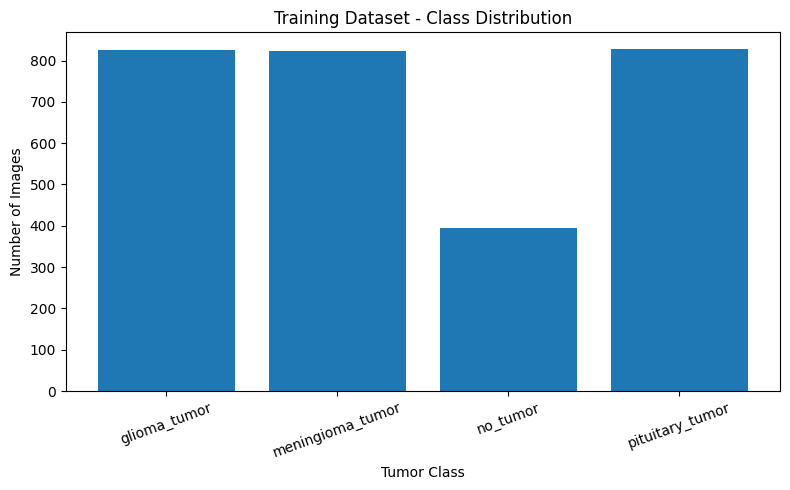

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(training_df["Class"], training_df["Image_Count"])

plt.title("Training Dataset - Class Distribution")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [13]:
training_df["Percentage"] = (
    training_df["Image_Count"] / training_df["Image_Count"].sum()
) * 100

training_df

,Class,Image_Count,Percentage
0,glioma_tumor,826,28.780488
1,meningioma_tumor,822,28.641115
2,no_tumor,395,13.763066
3,pituitary_tumor,827,28.815331


## 4. Dataset Inspection

This section examines the MRI images in the dataset to understand their visual
characteristics, dimensions, image format, and overall quality before applying
preprocessing techniques.

### 4.1 Sample MRI Images

This section displays one sample MRI image from each class in the training
dataset. This allows us to visually inspect the different classes before
performing further analysis and preprocessing.

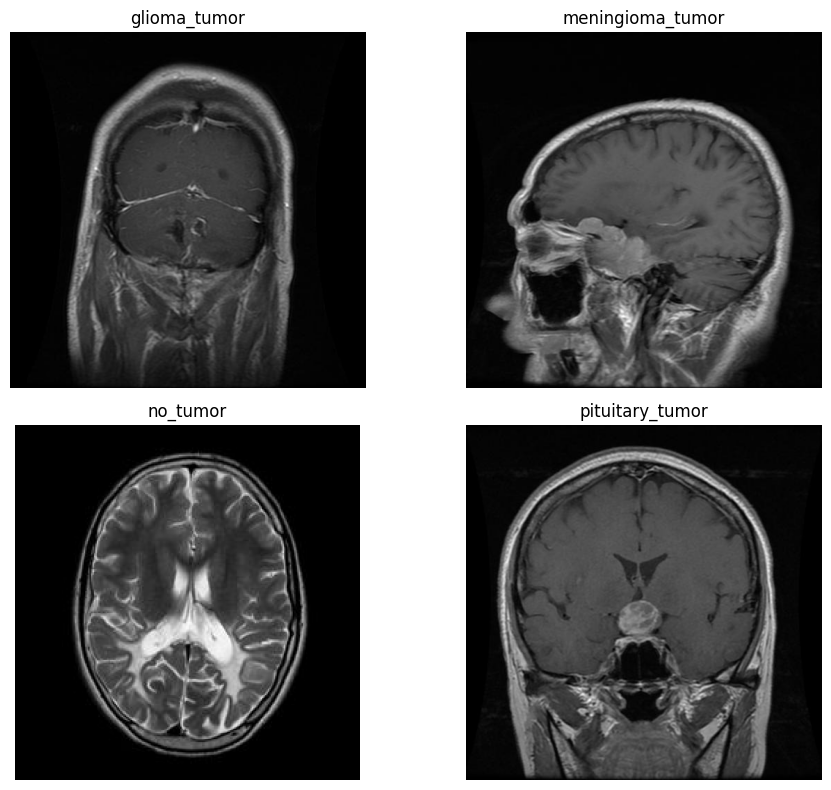

In [14]:
import random

classes = os.listdir(training_path)

plt.figure(figsize=(10, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(training_path, class_name)
    
    image_files = os.listdir(class_path)
    image_file = random.choice(image_files)
    
    image_path = os.path.join(class_path, image_file)
    image = Image.open(image_path)
    
    plt.subplot(2, 2, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 4.2 Image Dimension Analysis

This section examines the dimensions of the MRI images in the training
dataset. Understanding the original image dimensions is important because
the images will later need to be resized to a consistent input size for
the ResNet50 model.

In [15]:
for class_name in classes:
    class_path = os.path.join(training_path, class_name)
    image_files = os.listdir(class_path)
    
    image_path = os.path.join(class_path, image_files[0])
    image = Image.open(image_path)
    
    print(class_name)
    print("Image size:", image.size)
    print("Image mode:", image.mode)
    print()

glioma_tumor
Image size: (512, 512)
Image mode: RGB

meningioma_tumor
Image size: (512, 512)
Image mode: RGB

no_tumor
Image size: (350, 350)
Image mode: RGB

pituitary_tumor
Image size: (512, 512)
Image mode: RGB



### 4.2.1 Complete Image Dimension Analysis

The previous analysis examined one sample image from each class. This section
extends the analysis to all training images to identify whether different
image dimensions are present throughout the dataset.

In [18]:
valid_extensions = (".jpg", ".jpeg", ".png")

image_dimensions = []

for class_name in classes:
    class_path = os.path.join(training_path, class_name)

    for image_file in os.listdir(class_path):
        if image_file.lower().endswith(valid_extensions):
            image_path = os.path.join(class_path, image_file)

            image = Image.open(image_path)
            image_dimensions.append(image.size)

print("Total images checked:", len(image_dimensions))
print("Different image sizes:", len(set(image_dimensions)))

Total images checked: 2870
Different image sizes: 361


### 4.2.2 Most Common Image Dimensions

The following analysis identifies the most frequently occurring image
dimensions in the training dataset.

In [19]:
from collections import Counter

dimension_counts = Counter(image_dimensions)

print("Most common image sizes:")

for dimension, count in dimension_counts.most_common(10):
    print(dimension, ":", count, "images")

Most common image sizes:
(512, 512) : 2309 images
(236, 236) : 46 images
(225, 225) : 30 images
(442, 442) : 15 images
(256, 256) : 15 images
(630, 630) : 14 images
(350, 350) : 10 images
(201, 251) : 8 images
(236, 251) : 4 images
(236, 260) : 4 images


### 4.3 Image Width and Height Statistics

This section calculates the minimum, maximum, and average width and height
of the MRI images in the training dataset.

In [20]:
widths = [dimension[0] for dimension in image_dimensions]
heights = [dimension[1] for dimension in image_dimensions]

print("Minimum width:", min(widths))
print("Maximum width:", max(widths))

print("Minimum height:", min(heights))
print("Maximum height:", max(heights))

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

Minimum width: 180
Maximum width: 1375
Minimum height: 198
Maximum height: 1446
Average width: 480.1094076655052
Average height: 481.41637630662024


### 4.4 Image Mode and Channel Analysis

This section examines the image modes in the dataset to determine how the
MRI images are represented, such as RGB or grayscale.

In [21]:
image_modes = Counter()

for class_name in classes:
    class_path = os.path.join(training_path, class_name)
    
    for image_file in os.listdir(class_path):
        if image_file.lower().endswith(valid_extensions):
            image_path = os.path.join(class_path, image_file)
            
            image = Image.open(image_path)
            image_modes[image.mode] += 1

print("Image modes:")

for mode, count in image_modes.items():
    print(mode, ":", count)

Image modes:
RGB : 2870


### 4.5 Corrupted Image Check

This section checks whether the MRI image files can be successfully opened
and verified before further preprocessing.

In [22]:
corrupted_images = []

for class_name in classes:
    class_path = os.path.join(training_path, class_name)
    
    for image_file in os.listdir(class_path):
        if image_file.lower().endswith(valid_extensions):
            image_path = os.path.join(class_path, image_file)
            
            try:
                image = Image.open(image_path)
                image.verify()
            except Exception:
                corrupted_images.append(image_path)

print("Corrupted images:", len(corrupted_images))

Corrupted images: 0


## 5. Pixel Intensity Analysis

Pixel intensity represents the brightness of each pixel in an image. This
section analyzes the distribution of pixel intensity values in the MRI images
to understand their brightness and contrast characteristics before
preprocessing.

### 5.1 Pixel Intensity Distribution

A histogram is used to visualize how frequently different pixel intensity
values occur in a sample MRI image.

In [23]:
sample_class = classes[0]
sample_class_path = os.path.join(training_path, sample_class)

sample_image_file = os.listdir(sample_class_path)[0]
sample_image_path = os.path.join(sample_class_path, sample_image_file)

sample_image = Image.open(sample_image_path).convert("L")

pixel_values = np.array(sample_image)

print("Minimum pixel value:", pixel_values.min())
print("Maximum pixel value:", pixel_values.max())
print("Average pixel value:", pixel_values.mean())

Minimum pixel value: 0
Maximum pixel value: 249
Average pixel value: 26.84729766845703


### 5.2 Pixel Intensity Histogram

The histogram shows the frequency of different pixel intensity values in
the selected MRI image.

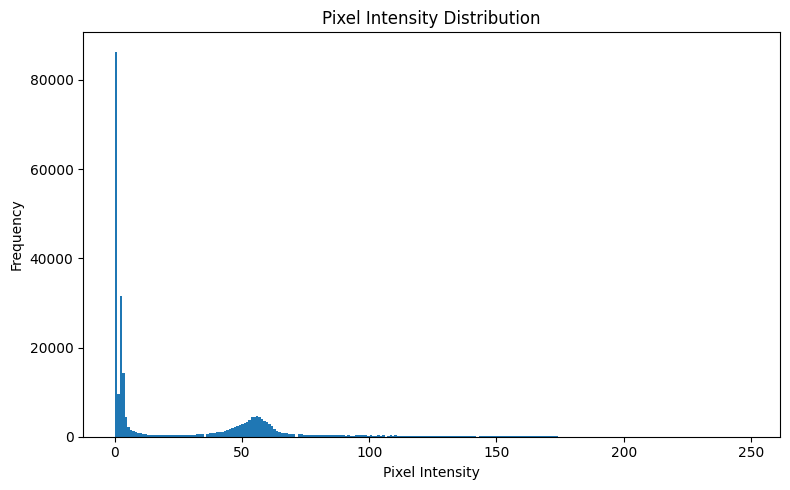

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(pixel_values.ravel(), bins=256)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### 5.3 Pixel Intensity Comparison Between Classes

This section compares the pixel intensity distributions of sample MRI images
from the four classes.

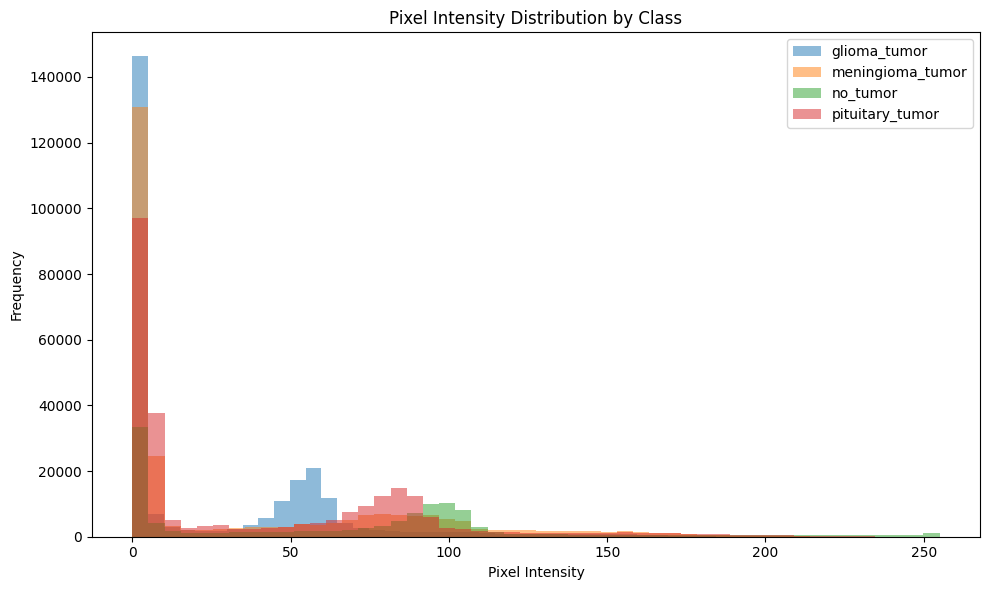

In [25]:
plt.figure(figsize=(10, 6))

for class_name in classes:
    class_path = os.path.join(training_path, class_name)
    image_files = os.listdir(class_path)

    image_path = os.path.join(class_path, image_files[0])
    image = Image.open(image_path).convert("L")

    pixel_values_class = np.array(image)

    plt.hist(
        pixel_values_class.ravel(),
        bins=50,
        alpha=0.5,
        label=class_name
    )

plt.title("Pixel Intensity Distribution by Class")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

## 6. Image Preprocessing

This section prepares the MRI images for use with the ResNet50 deep learning
model. The preprocessing steps include resizing the images to a consistent
input size and applying the preprocessing required by the ResNet50 model.

### 6.1 Image Resizing

MRI images may have different dimensions. To provide a consistent input to
ResNet50, all images will be resized to 224 × 224 pixels.

In [26]:
from PIL import Image

sample_class = classes[0]
sample_class_path = os.path.join(training_path, sample_class)

sample_image_file = os.listdir(sample_class_path)[0]
sample_image_path = os.path.join(sample_class_path, sample_image_file)

original_image = Image.open(sample_image_path).convert("RGB")
resized_image = original_image.resize((224, 224))

print("Original image size:", original_image.size)
print("Resized image size:", resized_image.size)

Original image size: (512, 512)
Resized image size: (224, 224)


### 6.1.1 Original vs Resized Image

The following visualization compares an original MRI image with its resized
224 × 224 version.

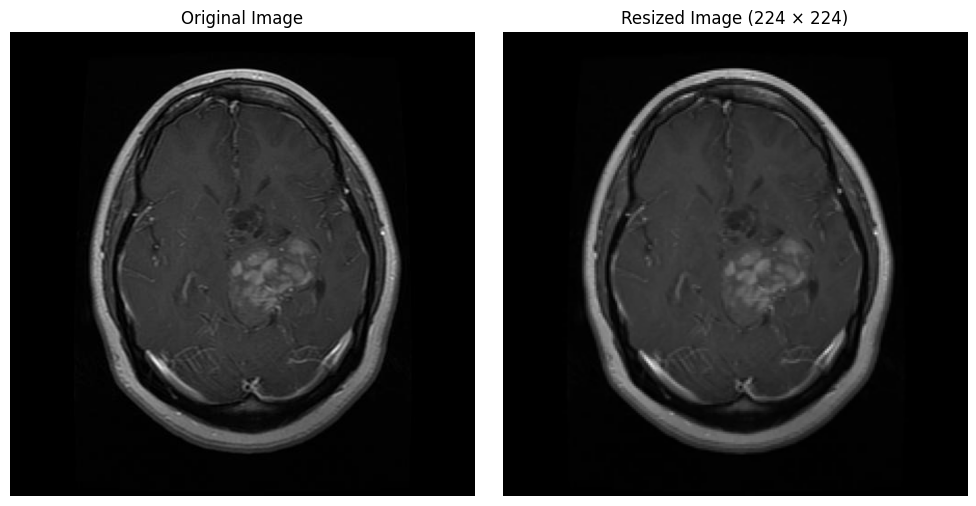

In [27]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(resized_image)
plt.title("Resized Image (224 × 224)")
plt.axis("off")

plt.tight_layout()
plt.show()

### 6.2 ResNet50 Preprocessing

After resizing, the images need to be prepared according to the preprocessing
requirements of ResNet50. The ResNet50 preprocessing function converts the
pixel values into the representation expected by the pretrained model.

### 6.2.1 Installing TensorFlow

TensorFlow provides the Keras framework required to load and preprocess images
for the ResNet50 deep learning model.

In [3]:
%pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.36.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.4.1-cp313-cp313-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.84.0-cp313-cp313-win_amd64.whl.metadata (3.9 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached h5py-3.14.0-cp313-cp313-win_amd64.whl.metadata (2.7 kB)
  Using cached m


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
from tensorflow.keras.applications.resnet50 import preprocess_input

print("ResNet50 preprocessing imported successfully!")

ResNet50 preprocessing imported successfully!


### 6.2 ResNet50 Preprocessing

After resizing, the images need to be prepared according to the preprocessing
requirements of ResNet50. The ResNet50 preprocessing function converts the
pixel values into the representation expected by the pretrained model.

In [28]:
from tensorflow.keras.applications.resnet50 import preprocess_input

print("ResNet50 preprocessing imported successfully!")

ResNet50 preprocessing imported successfully!


### 6.2.1 Applying ResNet50 Preprocessing

The resized image is converted into a NumPy array and passed through the
ResNet50 preprocessing function. This prepares the pixel values for use with
the pretrained ResNet50 model.

In [29]:
image_array = np.array(resized_image)

print("Before ResNet50 preprocessing:")
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

preprocessed_image = preprocess_input(image_array)

print("\nAfter ResNet50 preprocessing:")
print("Minimum pixel value:", preprocessed_image.min())
print("Maximum pixel value:", preprocessed_image.max())

Before ResNet50 preprocessing:
Minimum pixel value: 0
Maximum pixel value: 233

After ResNet50 preprocessing:
Minimum pixel value: -123.68
Maximum pixel value: 129.061


### 6.2.2 Visualizing the ResNet50 Preprocessing

The following visualization compares the original resized MRI image with the
image after ResNet50 preprocessing. The preprocessed image is converted to a
displayable range only for visualization.

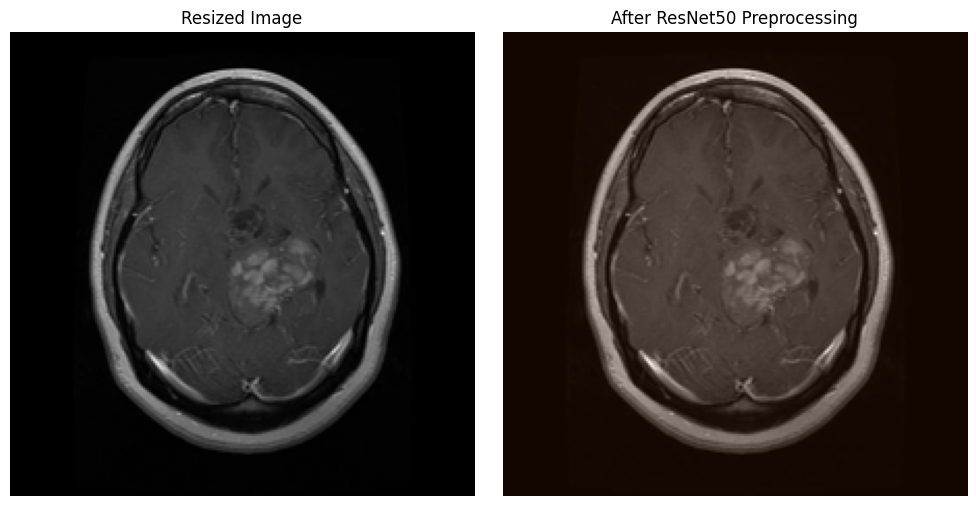

In [30]:
display_image = preprocessed_image.copy()

display_image = display_image - display_image.min()
display_image = display_image / display_image.max()

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(resized_image)
plt.title("Resized Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(display_image)
plt.title("After ResNet50 Preprocessing")
plt.axis("off")

plt.tight_layout()
plt.show()

### 6.3 Preparing Training and Testing Data

The dataset contains separate Training and Testing folders. The training
images will be used to train the model, while the testing images will be used
to evaluate the model after training.

The images will be resized to 224 × 224 pixels and ResNet50 preprocessing
will be applied during data loading.

### 6.3.1 Defining Image Size and Batch Size

ResNet50 expects input images with a size of 224 × 224 pixels and three color
channels (RGB). A batch size determines how many images are processed
together during training.

In [31]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: (224, 224)
Batch size: 32


### 6.3.2 Defining Class Names

The dataset contains four classes. The class names are explicitly defined so
that the same class-to-label mapping is maintained when loading both the
training and testing datasets.

In [32]:
class_names = [
    "glioma_tumor",
    "meningioma_tumor",
    "no_tumor",
    "pituitary_tumor"
]

print("Class names:")
for i, class_name in enumerate(class_names):
    print(i, ":", class_name)

Class names:
0 : glioma_tumor
1 : meningioma_tumor
2 : no_tumor
3 : pituitary_tumor


### 6.3.3 Loading the Training Dataset

The training images are loaded directly from the Training directory. Each
image is resized to 224 × 224 pixels and processed using the ResNet50
preprocessing function.

The dataset is loaded in batches rather than placing all images into memory
at once.

In [33]:
training_dataset = tf.keras.utils.image_dataset_from_directory(
    training_path,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print("Training dataset loaded successfully.")

Found 2870 files belonging to 4 classes.
Training dataset loaded successfully.


### 6.3.4 Loading the Testing Dataset

The testing images are loaded using the same image size and class mapping as
the training dataset. The testing dataset is not shuffled so that evaluation
remains deterministic.

In [34]:
testing_dataset = tf.keras.utils.image_dataset_from_directory(
    testing_path,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Testing dataset loaded successfully.")

Found 394 files belonging to 4 classes.
Testing dataset loaded successfully.


### 6.4 Applying ResNet50 Preprocessing

The loaded images currently contain pixel values in the standard image range.
The ResNet50 `preprocess_input` function will be applied to each batch of
images before they are passed to the model.

This ensures that the input data follows the preprocessing format expected by
the pretrained ResNet50 model.

In [36]:
def preprocess_dataset(images, labels):
    images = preprocess_input(images)
    return images, labels

### 6.4.1 Preprocessing the Training Dataset

The ResNet50 preprocessing function is mapped to the training dataset. The
preprocessing is performed as the image batches are accessed rather than
creating a separate copy of the entire dataset in memory.

In [37]:
training_dataset = training_dataset.map(preprocess_dataset)

print("Training preprocessing applied successfully.")

Training preprocessing applied successfully.


### 6.4.2 Preprocessing the Testing Dataset

The same ResNet50 preprocessing is applied to the testing dataset so that the
training and testing images use the same input representation.

In [38]:
testing_dataset = testing_dataset.map(preprocess_dataset)

print("Testing preprocessing applied successfully.")

Testing preprocessing applied successfully.


### 6.4.3 Verifying the Preprocessed Dataset

A single batch is extracted from the training dataset to verify the image
shape, label shape, and pixel value range after ResNet50 preprocessing.

In [39]:
images, labels = next(iter(training_dataset))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Minimum pixel value:", images.numpy().min())
print("Maximum pixel value:", images.numpy().max())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Minimum pixel value: -123.68
Maximum pixel value: 151.061


### 6.5 Data Augmentation

Data augmentation is used to create varied versions of training images by
applying small transformations. This can help improve the model's ability to
generalize to unseen MRI images.

Augmentation is applied only to the training dataset. The testing dataset is
kept unchanged so that it represents unseen data during evaluation.

### 6.5.1 Defining Data Augmentation

The following augmentation layers apply small transformations to training
images. These transformations are performed during training rather than
permanently changing the original MRI images.

In [40]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1)
])

print("Data augmentation pipeline created successfully.")

Data augmentation pipeline created successfully.


### 6.5.2 Visualizing Data Augmentation

A sample MRI image is passed through the augmentation pipeline several times
to demonstrate how the training images can be varied while preserving their
main visual characteristics.

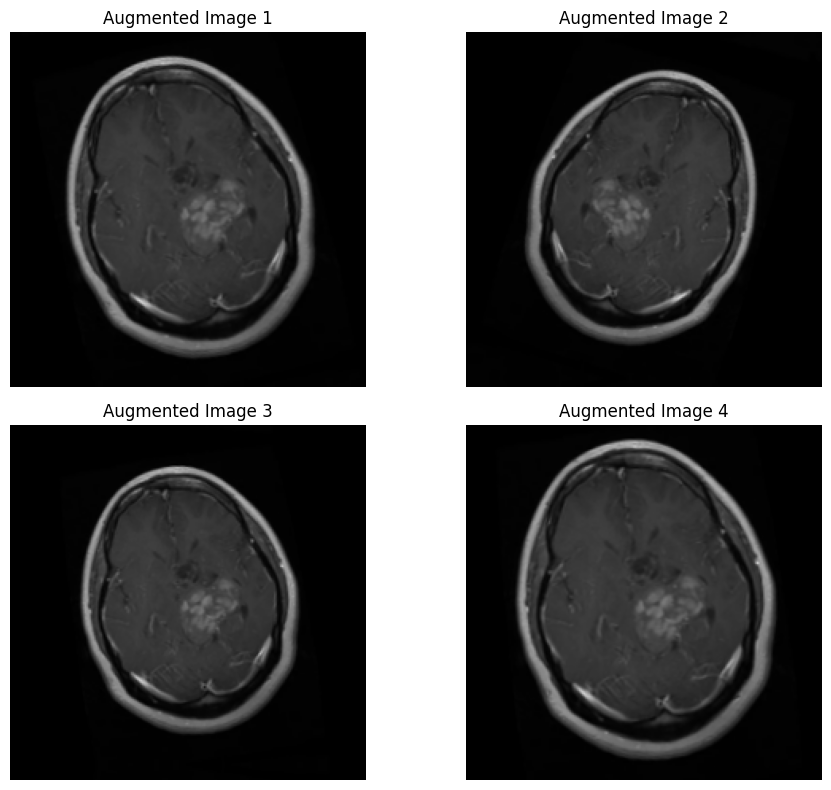

In [42]:
sample_image_for_augmentation = np.array(resized_image)

plt.figure(figsize=(10, 8))

for i in range(4):
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image_for_augmentation, axis=0),
        training=True
    )

    plt.subplot(2, 2, i + 1)
    plt.imshow(augmented_image[0].numpy().astype("uint8"))
    plt.title(f"Augmented Image {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### 6.6 Final Dataset Verification

The final training and testing datasets are checked to confirm that the
images have the correct dimensions, RGB channels, and class labels required
for the ResNet50 model.

In [43]:
training_images, training_labels = next(iter(training_dataset))
testing_images, testing_labels = next(iter(testing_dataset))

print("Training image batch shape:", training_images.shape)
print("Training label batch shape:", training_labels.shape)

print("Testing image batch shape:", testing_images.shape)
print("Testing label batch shape:", testing_labels.shape)

Training image batch shape: (32, 224, 224, 3)
Training label batch shape: (32,)
Testing image batch shape: (32, 224, 224, 3)
Testing label batch shape: (32,)


### 6.6.1 Checking Class Labels

The class labels are checked to ensure that the loaded datasets use the
expected four-class mapping.

In [45]:
print("Class names:")
for index, class_name in enumerate(class_names):
    print(index, ":", class_name)

print("\nTraining labels in first batch:")
print(training_labels.numpy())

print("\nTesting labels in first batch:")
print(testing_labels.numpy())

Class names:
0 : glioma_tumor
1 : meningioma_tumor
2 : no_tumor
3 : pituitary_tumor

Training labels in first batch:
[3 3 0 0 0 1 1 0 3 0 1 3 1 0 0 3 1 3 1 0 0 3 2 1 0 3 1 1 1 1 0 0]

Testing labels in first batch:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


### 6.6.2 Checking the Final Pixel Value Range

The pixel values are checked after ResNet50 preprocessing to confirm that the
preprocessing function has been applied to the loaded datasets.

In [46]:
print("Training dataset pixel range:")
print("Minimum:", training_images.numpy().min())
print("Maximum:", training_images.numpy().max())

print("\nTesting dataset pixel range:")
print("Minimum:", testing_images.numpy().min())
print("Maximum:", testing_images.numpy().max())

Training dataset pixel range:
Minimum: -123.68
Maximum: 150.84546

Testing dataset pixel range:
Minimum: -123.68
Maximum: 151.061
